# 提取时间步长61的UK站点气象数据

本脚本将从预测结果中提取第61个时间步的precipitation (pr)和temperature (tas)数据，并将其与UK站点信息进行匹配。

In [15]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

# 定义路径
pr_file = Path("../prediction/results_on_sites/emul_in_Y_modhighice_pr.nc")
tas_file = Path("../prediction/results_on_sites/emul_in_Y_modhighice_tas.nc")
sites_file = Path("UK_sites_index.res")

print("路径已定义")
print(f"PR 文件: {pr_file}")
print(f"TAS 文件: {tas_file}")
print(f"Sites 文件: {sites_file}")

路径已定义
PR 文件: ../prediction/results_on_sites/emul_in_Y_modhighice_pr.nc
TAS 文件: ../prediction/results_on_sites/emul_in_Y_modhighice_tas.nc
Sites 文件: UK_sites_index.res


## 步骤1：读取NC文件中的变量

In [16]:
# 读取NC文件
pr_data = xr.open_dataset(pr_file)
tas_data = xr.open_dataset(tas_file)

print("=== Precipitation (PR) 文件信息 ===")
print(pr_data)
print("\n=== Temperature (TAS) 文件信息 ===")
print(tas_data)

# 获取变量信息
pr_var = pr_data['var']  # precipitation
tas_var = tas_data['var']  # temperature

print(f"\nPR 形状: {pr_var.shape}")
print(f"TAS 形状: {tas_var.shape}")
print(f"PR 坐标范围: lat {float(pr_data['lat'].min()):.2f} to {float(pr_data['lat'].max()):.2f}")
print(f"           lon {float(pr_data['lon'].min()):.2f} to {float(pr_data['lon'].max()):.2f}")
print(f"TAS 坐标范围: lat {float(tas_data['lat'].min()):.2f} to {float(tas_data['lat'].max()):.2f}")
print(f"            lon {float(tas_data['lon'].min()):.2f} to {float(tas_data['lon'].max()):.2f}")

=== Precipitation (PR) 文件信息 ===
<xarray.Dataset> Size: 126MB
Dimensions:  (lat: 360, lon: 720, time: 122)
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -180.0 -179.5 -179.0 -178.5 ... 178.5 179.0 179.5
  * time     (time) float64 976B 2e+05 2e+05 2e+05 2e+05 ... 2e+05 2e+05 2e+05
Data variables:
    var      (time, lat, lon) float32 126MB ...
Attributes: (12/23)
    CDI:                      Climate Data Interface version 2.4.0 (https://m...
    Conventions:              CF-1.5
    GDAL_activity_id:         observation
    GDAL_cf_standard_name:    precipitation_flux
    GDAL_citation1:           Karger, D.N., Conrad, O., Böhner, J., Kawohl, T...
    GDAL_contact:             dirk.karger@wsl.ch
    ...                       ...
    GDAL_variable_unit:       m s-1
    GDAL_version:             2.1
    GDAL:                     GDAL 3.4.1, released 2021/12/27
    history:                  Thu Feb 12 21:34:18 2

## 步骤2：读取UK站点位置数据

In [17]:
# 读取UK站点数据
sites_df = pd.read_csv(sites_file)
print("=== UK站点数据 ===")
print(sites_df.head(10))
print(f"\n总计 {len(sites_df)} 个站点")

# 获取站点的实际坐标
site_lons = sites_df['lon'].values
site_lats = sites_df['lat'].values

print(f"\n实际Lon范围: {site_lons.min():.2f} to {site_lons.max():.2f}")
print(f"实际Lat范围: {site_lats.min():.2f} to {site_lats.max():.2f}")

=== UK站点数据 ===
   site_num  lon_index  lat_index   lon    lat
0         1         11          2 -5.75  50.25
1         2         12          2 -5.25  50.25
2         3         12          5 -5.25  51.75
3         4         12          6 -5.25  52.25
4         5         13          2 -4.75  50.25
5         6         13          3 -4.75  50.75
6         7         13          5 -4.75  51.75
7         8         13          6 -4.75  52.25
8         9         13          7 -4.75  52.75
9        10         13          8 -4.75  53.25

总计 112 个站点

实际Lon范围: -5.75 to 1.75
实际Lat范围: 50.25 to 55.75


## 步骤3：验证坐标系统一致性

检查NC文件中的坐标与res文件中记录的索引是否对应

In [18]:
# 获取NC文件中的坐标数组
nc_lons = pr_data['lon'].values
nc_lats = pr_data['lat'].values

print("NC文件坐标范围验证:")
print("=" * 50)
print(f"NC Lon范围: {nc_lons.min():.2f} to {nc_lons.max():.2f}")
print(f"NC Lat范围: {nc_lats.min():.2f} to {nc_lats.max():.2f}")
print(f"\nUK站点Lon范围: {site_lons.min():.2f} to {site_lons.max():.2f}")
print(f"UK站点Lat范围: {site_lats.min():.2f} to {site_lats.max():.2f}")

# 检查几个样本点的坐标匹配情况
print("\n样本点坐标验证:")
print("-" * 50)

test_samples = [0, 50, 111]

for idx in test_samples:
    site_row = sites_df.iloc[idx]
    site_num = site_row['site_num']
    res_lon = site_row['lon']
    res_lat = site_row['lat']
    
    # 找到最接近的NC网格点
    lon_idx = np.argmin(np.abs(nc_lons - res_lon))
    lat_idx = np.argmin(np.abs(nc_lats - res_lat))
    
    nc_lon = nc_lons[lon_idx]
    nc_lat = nc_lats[lat_idx]
    
    print(f"站点 {site_num}:")
    print(f"  RES文件坐标: lon={res_lon:.2f}, lat={res_lat:.2f}")
    print(f"  最近NC网格点: lon={nc_lon:.2f}, lat={nc_lat:.2f}")
    print(f"  距离偏差: Δlon={abs(nc_lon-res_lon):.4f}, Δlat={abs(nc_lat-res_lat):.4f}")
    print()

NC文件坐标范围验证:
NC Lon范围: -180.00 to 179.50
NC Lat范围: -89.75 to 89.75

UK站点Lon范围: -5.75 to 1.75
UK站点Lat范围: 50.25 to 55.75

样本点坐标验证:
--------------------------------------------------
站点 1.0:
  RES文件坐标: lon=-5.75, lat=50.25
  最近NC网格点: lon=-6.00, lat=50.25
  距离偏差: Δlon=0.2500, Δlat=0.0000

站点 51.0:
  RES文件坐标: lon=-2.25, lat=53.25
  最近NC网格点: lon=-2.50, lat=53.25
  距离偏差: Δlon=0.2500, Δlat=0.0000

站点 112.0:
  RES文件坐标: lon=1.75, lat=52.75
  最近NC网格点: lon=1.50, lat=52.75
  距离偏差: Δlon=0.2500, Δlat=0.0000



## 步骤4：提取时间步长61的数据

提取PR和TAS在所有UK站点的值（第61个时间步，索引为60）

In [19]:
# 提取第61步（索引60）的所有数据
time_step_idx = 60  # 从0开始计数，61对应索引60

pr_timestep = pr_data['var'].isel(time=time_step_idx).values  # 形状: (lat, lon)
tas_timestep = tas_data['var'].isel(time=time_step_idx).values  # 形状: (lat, lon)

nc_lons = pr_data['lon'].values
nc_lats = pr_data['lat'].values

print(f"提取时间步长: {time_step_idx + 1} (索引 {time_step_idx})")
print(f"PR 数据形状: {pr_timestep.shape}")
print(f"TAS 数据形状: {tas_timestep.shape}")
print(f"\nPR 数据范围: {pr_timestep.min():.6e} to {pr_timestep.max():.6e} (单位: m/s)")
print(f"TAS 数据范围: {tas_timestep.min():.2f} to {tas_timestep.max():.2f} (单位: K)")

# 为每个站点提取数据 - 使用实际的lon/lat值来查找正确的索引
site_pr_values = []
site_tas_values = []

print("\n根据实际lon/lat值提取数据...")

for idx, row in sites_df.iterrows():
    site_lon = row['lon']
    site_lat = row['lat']
    
    # 使用NC文件中的坐标值来找到最近的网格点
    # 使用argmin找到最近的索引
    lon_idx = np.argmin(np.abs(nc_lons - site_lon))
    lat_idx = np.argmin(np.abs(nc_lats - site_lat))
    
    pr_val = pr_timestep[lat_idx, lon_idx]
    tas_val = tas_timestep[lat_idx, lon_idx]
    
    site_pr_values.append(pr_val)
    site_tas_values.append(tas_val)

site_pr_values = np.array(site_pr_values)
site_tas_values = np.array(site_tas_values)

print(f"✓ 成功提取 {len(site_pr_values)} 个站点的数据")
print(f"PR 值范围: {site_pr_values.min():.6e} to {site_pr_values.max():.6e}")
print(f"TAS 值数量: {len(site_tas_values)}")
print(f"TAS 值范围: {site_tas_values.min():.2f} to {site_tas_values.max():.2f}")

提取时间步长: 61 (索引 60)
PR 数据形状: (360, 720)
TAS 数据形状: (360, 720)

PR 数据范围: 1.408333e-11 to 2.074244e-07 (单位: m/s)
TAS 数据范围: 230.10 to 303.70 (单位: K)

根据实际lon/lat值提取数据...
✓ 成功提取 112 个站点的数据
PR 值范围: 3.198717e-08 to 4.572825e-08
TAS 值数量: 112
TAS 值范围: 276.50 to 281.60


## 步骤5：单位转换

- Precipitation: m/s → mm/month (乘以 60×60×24×1000×30)
- Temperature: K → °C (减去273.15)

In [20]:
# 单位转换
# PR: m/s -> mm/month
# 转换系数: 60 秒/分 * 60 分/时 * 24 时/天 * 1000 mm/m * 30 天/月 = 2.592e9
pr_conversion_factor = 60.0 * 60.0 * 24.0 * 1000.0 * 30.0
site_pr_converted = site_pr_values * pr_conversion_factor  # mm/month

# TAS: K -> °C
tas_conversion_offset = 273.15
site_tas_converted = site_tas_values - tas_conversion_offset  # °C

print("单位转换信息:")
print("=" * 50)
print(f"PR 转换系数: {pr_conversion_factor:.0f}")
print(f"PR 原始范围: {site_pr_values.min():.6e} to {site_pr_values.max():.6e} m/s")
print(f"PR 转换后范围: {site_pr_converted.min():.2f} to {site_pr_converted.max():.2f} mm/month")
print()
print(f"TAS 原始范围: {site_tas_values.min():.2f} to {site_tas_values.max():.2f} K")
print(f"TAS 转换后范围: {site_tas_converted.min():.2f} to {site_tas_converted.max():.2f} °C")

单位转换信息:
PR 转换系数: 2592000000
PR 原始范围: 3.198717e-08 to 4.572825e-08 m/s
PR 转换后范围: 82.91 to 118.53 mm/month

TAS 原始范围: 276.50 to 281.60 K
TAS 转换后范围: 3.35 to 8.45 °C


## 步骤6：导出数据到TXT文件

按照指定格式写入结果: 站点号, TAS, PR

In [25]:
# 创建输出文件名
output_file = Path("site_values_timestep61.txt")

# 构建数据框
output_df = pd.DataFrame({
    'site_num': sites_df['site_num'].values,
    'tas_celsius': site_tas_converted,
    'pr_mm_per_month': site_pr_converted
})

# 写入TXT文件
with open(output_file, 'w') as f:
    # 写入描述性标题
    f.write("# Extracted UK site climate data for timestep 61\n")
    f.write("# Source PR file: ../prediction/results_on_sites/emul_in_Y_modhighice_pr.nc\n")
    f.write("# Source TAS file: ../prediction/results_on_sites/emul_in_Y_modhighice_tas.nc\n")
    f.write("# Site location file: UK_sites_index.res\n")
    f.write("# Coordinates used for extraction: actual lon/lat values from UK_sites_index.res\n")
    f.write("# Extraction method: nearest grid cell on the original global lon/lat grid (-180 to 180, -90 to 90)\n")
    f.write("# Units: tas_celsius in degree C; pr_mm_per_month in mm/month\n")
    f.write("site_num\ttas_celsius\tpr_mm_per_month\n")
    
    # 写入数据
    for idx, row in output_df.iterrows():
        f.write(f"{int(row['site_num'])}\t{row['tas_celsius']:.2f}\t{row['pr_mm_per_month']:.2f}\n")

print(f"数据已写入: {output_file}")
print(f"总计写入 {len(output_df)} 行")
print("\n前10行预览:")
with open(output_file, 'r') as f:
    for i, line in enumerate(f):
        if i < 10:
            print(line.rstrip())
        else:
            break

数据已写入: site_values_timestep61.txt
总计写入 112 行

前10行预览:
# Extracted UK site climate data for timestep 61
# Source PR file: ../prediction/results_on_sites/emul_in_Y_modhighice_pr.nc
# Source TAS file: ../prediction/results_on_sites/emul_in_Y_modhighice_tas.nc
# Site location file: UK_sites_index.res
# Coordinates used for extraction: actual lon/lat values from UK_sites_index.res
# Extraction method: nearest grid cell on the original global lon/lat grid (-180 to 180, -90 to 90)
# Units: tas_celsius in degree C; pr_mm_per_month in mm/month
site_num	tas_celsius	pr_mm_per_month
1	8.45	118.53
2	8.15	115.82


## 步骤7：验证输出文件

## 步骤8：数据可视化

对比全球数据和UK站点提取的数据

/var/folders/31/lmwyg8_x08j0p9p16_pnmtmr0000gp/T/ipykernel_85133/2617221091.py:68: UserWarning: Glyph 20351 (\N{CJK UNIFIED IDEOGRAPH-4F7F}) missing from font(s) DejaVu Sans.
  plt.savefig('timestep61_data_comparison.png', dpi=150, bbox_inches='tight')
/var/folders/31/lmwyg8_x08j0p9p16_pnmtmr0000gp/T/ipykernel_85133/2617221091.py:68: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.savefig('timestep61_data_comparison.png', dpi=150, bbox_inches='tight')
/var/folders/31/lmwyg8_x08j0p9p16_pnmtmr0000gp/T/ipykernel_85133/2617221091.py:68: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.savefig('timestep61_data_comparison.png', dpi=150, bbox_inches='tight')
/var/folders/31/lmwyg8_x08j0p9p16_pnmtmr0000gp/T/ipykernel_85133/2617221091.py:68: UserWarning: Glyph 38469 (\N{CJK UNIFIED IDEOGRAPH-9645}) missing from font(s) DejaVu Sans.
  plt.savefig('timestep61_data_comparison.png', dpi=150, bbox_inch

✓ 图表已保存: timestep61_data_comparison.png


/Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/TONIC-Oligocene/NWS_emulation/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20351 (\N{CJK UNIFIED IDEOGRAPH-4F7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/TONIC-Oligocene/NWS_emulation/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/TONIC-Oligocene/NWS_emulation/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/TONIC-Oligocene/NWS_emulation/.venv/lib/python3.9/

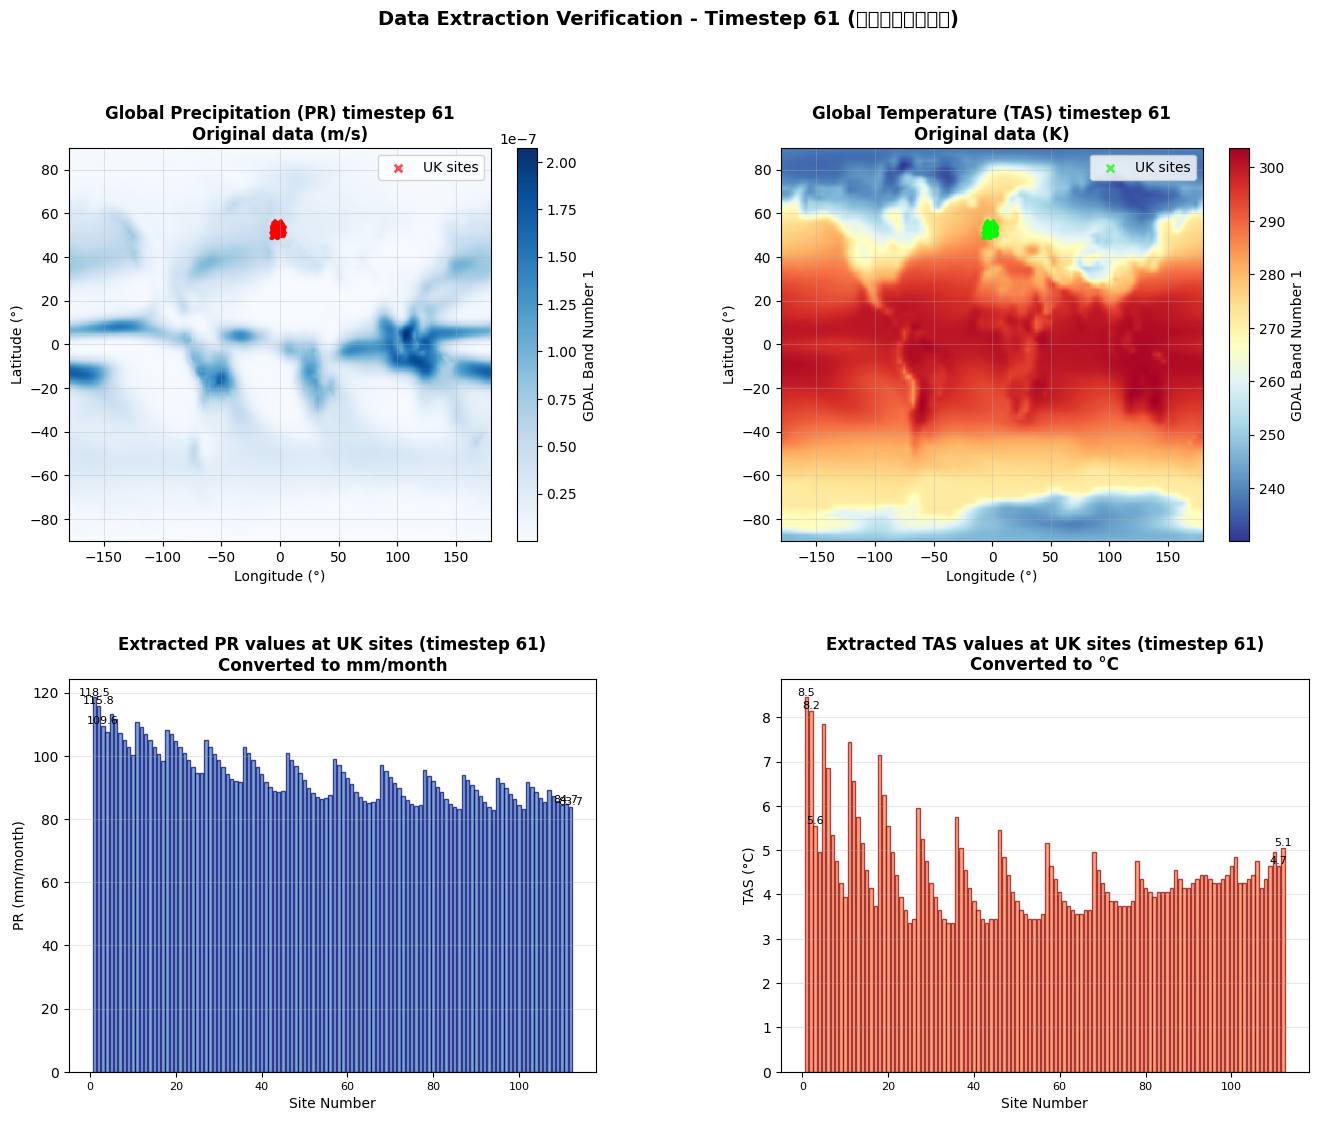


数据统计摘要:
全球数据统计 (timestep 61):
  PR - 最小值: 1.408333e-11 m/s, 最大值: 2.074244e-07 m/s
  TAS - 最小值: 230.10 K, 最大值: 303.70 K

UK站点提取数据统计:
  PR - 最小值: 82.91 mm/month, 最大值: 118.53 mm/month
       平均值: 93.93 mm/month, 标准差: 8.24
  TAS - 最小值: 3.35 °C, 最大值: 8.45 °C
        平均值: 4.47 °C, 标准差: 1.01


In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# 获取NC坐标
nc_lons = pr_data['lon'].values
nc_lats = pr_data['lat'].values

# 创建一个大图表 (2行2列)
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.35)

# ==================== 1. 全球PR数据 (用实际地理坐标) ====================
ax1 = fig.add_subplot(gs[0, 0])
# 使用xarray直接绘制，自动处理坐标
pr_data['var'].isel(time=60).plot(ax=ax1, cmap='Blues', add_colorbar=True)
ax1.set_title('Global Precipitation (PR) timestep 61\nOriginal data (m/s)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude (°)')
ax1.set_ylabel('Latitude (°)')

# 在UK站点位置标记
ax1.scatter(site_lons, site_lats, c='red', s=30, alpha=0.7, marker='x', label='UK sites', linewidths=2)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ==================== 2. 全球TAS数据 (用实际地理坐标) ====================
ax2 = fig.add_subplot(gs[0, 1])
tas_data['var'].isel(time=60).plot(ax=ax2, cmap='RdYlBu_r', add_colorbar=True)
ax2.set_title('Global Temperature (TAS) timestep 61\nOriginal data (K)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude (°)')
ax2.set_ylabel('Latitude (°)')

# 在UK站点位置标记
ax2.scatter(site_lons, site_lats, c='lime', s=30, alpha=0.7, marker='x', label='UK sites', linewidths=2)
ax2.legend()
ax2.grid(True, alpha=0.3)

# ==================== 3. UK站点PR数据分布 ====================
ax3 = fig.add_subplot(gs[1, 0])
site_nums = sites_df['site_num'].values
bars1 = ax3.bar(site_nums, site_pr_converted, color='steelblue', alpha=0.7, edgecolor='navy')
ax3.set_title('Extracted PR values at UK sites (timestep 61)\nConverted to mm/month', fontsize=12, fontweight='bold')
ax3.set_xlabel('Site Number')
ax3.set_ylabel('PR (mm/month)')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', labelsize=8)

# 添加值标签到前几个和最后几个bar
for i in [0, 1, 2, len(site_nums)-2, len(site_nums)-1]:
    ax3.text(site_nums[i], site_pr_converted[i], f'{site_pr_converted[i]:.1f}', 
             ha='center', va='bottom', fontsize=8)

# ==================== 4. UK站点TAS数据分布 ====================
ax4 = fig.add_subplot(gs[1, 1])
bars2 = ax4.bar(site_nums, site_tas_converted, color='coral', alpha=0.7, edgecolor='darkred')
ax4.set_title('Extracted TAS values at UK sites (timestep 61)\nConverted to °C', fontsize=12, fontweight='bold')
ax4.set_xlabel('Site Number')
ax4.set_ylabel('TAS (°C)')
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', labelsize=8)

# 添加值标签到前几个和最后几个bar
for i in [0, 1, 2, len(site_nums)-2, len(site_nums)-1]:
    ax4.text(site_nums[i], site_tas_converted[i], f'{site_tas_converted[i]:.1f}', 
             ha='center', va='bottom', fontsize=8)

plt.suptitle('Data Extraction Verification - Timestep 61 (使用实际地理坐标)', fontsize=14, fontweight='bold', y=0.995)
plt.savefig('timestep61_data_comparison.png', dpi=150, bbox_inches='tight')
print("✓ 图表已保存: timestep61_data_comparison.png")
plt.show()

print("\n数据统计摘要:")
print("=" * 60)
print("全球数据统计 (timestep 61):")
print(f"  PR - 最小值: {pr_timestep.min():.6e} m/s, 最大值: {pr_timestep.max():.6e} m/s")
print(f"  TAS - 最小值: {tas_timestep.min():.2f} K, 最大值: {tas_timestep.max():.2f} K")
print("\nUK站点提取数据统计:")
print(f"  PR - 最小值: {site_pr_converted.min():.2f} mm/month, 最大值: {site_pr_converted.max():.2f} mm/month")
print(f"       平均值: {site_pr_converted.mean():.2f} mm/month, 标准差: {site_pr_converted.std():.2f}")
print(f"  TAS - 最小值: {site_tas_converted.min():.2f} °C, 最大值: {site_tas_converted.max():.2f} °C")
print(f"        平均值: {site_tas_converted.mean():.2f} °C, 标准差: {site_tas_converted.std():.2f}")

In [23]:
# 验证文件内容
if output_file.exists():
    print(f"✓ 文件已成功创建: {output_file}")
    print(f"✓ 文件大小: {output_file.stat().st_size} 字节")
    print("\n文件内容预览 (前15行):")
    print("-" * 50)
    with open(output_file, 'r') as f:
        for i, line in enumerate(f):
            if i < 15:
                print(line.rstrip())
            else:
                break
    print("-" * 50)
    print(f"\n总计生成 {len(output_df)} 个站点的数据")
else:
    print("✗ 文件创建失败")

✓ 文件已成功创建: site_values_timestep61.txt
✓ 文件大小: 1636 字节

文件内容预览 (前15行):
--------------------------------------------------
site_num	tas_celsius	pr_mm_per_month
1	8.45	118.53
2	8.15	115.82
3	5.55	109.58
4	4.95	107.58
5	7.85	113.22
6	6.85	111.53
7	5.35	107.17
8	4.75	105.15
9	4.25	102.89
10	3.95	100.34
11	7.45	110.66
12	6.55	109.14
13	5.75	106.99
14	5.15	104.93
--------------------------------------------------

总计生成 112 个站点的数据
